使用 10-monkeys 数据集。

https://www.kaggle.com/datasets/slothkong/10-monkey-species

**图片类数据集分析**
1. 不同类别的图片放一个文件夹（10-monkeys 就是这个类型）
2. 所有的图片都放在一个文件夹，给你一个 excel，一列是图片名，一列是类别

In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input"))

# Any results you write to the current directory are saved as output.

['validation', 'monkey_labels.txt', '10449_44567_upload_training.zip', '10449_44567_upload_validation.zip', 'training']


In [ ]:
!python3 --version

In [ ]:
!nvidia-smi

In [18]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import sklearn
import sys
import tensorflow as tf
import time

from tensorflow import keras

print(tf.__version__)
print(sys.version_info)
for module in mpl, np, pd, sklearn, tf, keras:
    print(module.__name__, module.__version__)

2.2.0
sys.version_info(major=3, minor=6, micro=9, releaselevel='final', serial=0)
matplotlib 3.2.1
numpy 1.18.5
pandas 1.0.4
sklearn 0.23.1
tensorflow 2.2.0
tensorflow.keras 2.3.0-tf


In [ ]:
import tensorflow as tf

print(f"TensorFlow Version: {tf.__version__}")

gpus = tf.config.list_physical_devices('GPU')
print(f"Num GPUs Available: {len(gpus)}")

if gpus:
    print(f"GPUs available: {gpus}")
    try:
        # 打印每个GPU的详细信息
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True) # 推荐设置，按需分配显存
            print(f"Details for {gpu.name}:")
            # 可以尝试执行一个小操作来确认
        print("GPU is available and TensorFlow can see it!")

        # 尝试一个简单的GPU运算
        print("\nAttempting a simple computation on GPU...")
        with tf.device('/GPU:0'): # 明确指定在第一个GPU上运行
            a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
            b = tf.constant([[1.0, 2.0], [3.0, 4.0]])
            c = tf.matmul(a, b)
        print("Matrix multiplication result from GPU:")
        print(c.numpy())
        print("If no errors occurred, GPU is working!")

    except RuntimeError as e:
        print(f"RuntimeError during GPU setup or test: {e}")
else:
    print("GPU not available to TensorFlow. TensorFlow will run on CPU.")

In [19]:
train_dir = "../input/training"
valid_dir = "../input/validation"
label_file = "../input/monkey_labels.txt"
print(os.path.exists(train_dir))
print(os.path.exists(valid_dir))
print(os.path.exists(label_file))

print(os.listdir(train_dir))
print(os.listdir(valid_dir))

True
True
True
['n6', 'n5', 'n2', 'n1', 'n3', 'n0', 'n8', 'n7', 'n9', 'n4']
['n6', 'n5', 'n2', 'n1', 'n3', 'n0', 'n8', 'n7', 'n9', 'n4']


In [20]:
labels = pd.read_csv(label_file, header=0)
print(labels)

   Label     Latin Name              Common Name                     \
0  n0         alouatta_palliata\t    mantled_howler                   
1  n1        erythrocebus_patas\t    patas_monkey                     
2  n2        cacajao_calvus\t        bald_uakari                      
3  n3        macaca_fuscata\t        japanese_macaque                 
4  n4       cebuella_pygmea\t        pygmy_marmoset                   
5  n5       cebus_capucinus\t        white_headed_capuchin            
6  n6       mico_argentatus\t        silvery_marmoset                 
7  n7      saimiri_sciureus\t        common_squirrel_monkey           
8  n8       aotus_nigriceps\t        black_headed_night_monkey        
9  n9       trachypithecus_johnii    nilgiri_langur                   

    Train Images    Validation Images  
0             131                  26  
1             139                  28  
2             137                  27  
3             152                  30  
4             131 

另有一些其他的图像处理方式，什么是错切：
https://blog.csdn.net/frozenshore/article/details/50283583

In [ ]:
height = 128
width = 128
channels = 3
batch_size = 64
num_classes = 10

# 图片增强
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale = 1./255, # 图片中的每个像素点都乘以1/255
    rotation_range = 40, # 把图形随机旋转一个角度，在0-40度之间
    width_shift_range = 0.2, # 位移，0-20%之间选择做偏移
    height_shift_range = 0.2, # 垂直方向位移，如果是0-1之间的数，就是比例，大于1就是像素
    shear_range = 0.2, # 剪切强度（逆时针剪切角，以度为单位）
    zoom_range = 0.2, # 缩放强度
    horizontal_flip = True, # 水平随机翻转
    fill_mode = 'nearest', # 图形放大后，有些地方需要填充，
#  可以是“常数”，“最近”，“反射”或“环绕”之一。默认值为“最近”。输入边界之外的点将根据给定模式进行填充
)

# 读取图片，把不同类别的图片，自动和标签对应上（根据文件夹的名字）
train_generator = train_datagen.flow_from_directory(train_dir,
                                                    # 生成图片多大
                                                   target_size = (height, width),
                                                    # 生成的图片以多少张为一组
                                                   batch_size = batch_size,
                                                   seed = 7,
                                                   shuffle = True,
                                                    #one-hot编码后的一种模式
                                                   class_mode = "categorical")

# 对验证集必须做一个值的缩放，其他的不需要做
valid_datagen = keras.preprocessing.image.ImageDataGenerator(rescale = 1./255)
valid_generator = valid_datagen.flow_from_directory(valid_dir,
                                                    target_size = (height, width),
                                                    batch_size = batch_size,
                                                    seed = 7,
                                                    shuffle = False,
                                                    class_mode = "categorical")

train_num = train_generator.samples
valid_num = valid_generator.samples
print(train_num, valid_num)

Found 1098 images belonging to 10 classes.
Found 272 images belonging to 10 classes.
1098 272


In [22]:
for i in range(2):
    x, y = train_generator.next()
    print(x.shape, y.shape)
    print(y)

(64, 128, 128, 3) (64, 10)
[[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.

In [23]:
model = keras.models.Sequential([
    #第一组卷积
    keras.layers.Conv2D(filters=32, kernel_size=3, padding='same',
                        activation='relu', input_shape=[width, height, channels]),
    keras.layers.Conv2D(filters=32, kernel_size=3, padding='same',
                        activation='relu'),
    keras.layers.MaxPool2D(pool_size=2),
    #第二组翻倍
    keras.layers.Conv2D(filters=64, kernel_size=3, padding='same',
                        activation='relu'),
    keras.layers.Conv2D(filters=64, kernel_size=3, padding='same',
                        activation='relu'),
    keras.layers.MaxPool2D(pool_size=2),
    #第三组再翻倍
    keras.layers.Conv2D(filters=128, kernel_size=3, padding='same',
                        activation='relu'),
    keras.layers.Conv2D(filters=128, kernel_size=3, padding='same',
                        activation='relu'),
    keras.layers.MaxPool2D(pool_size=2),
    keras.layers.Flatten(),
    #展平后，和全连接层做连接
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax'),
])

model.compile(loss="categorical_crossentropy",
              optimizer="adam", metrics=['accuracy'])
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_12 (Conv2D)           (None, 128, 128, 32)      896       
_________________________________________________________________
conv2d_13 (Conv2D)           (None, 128, 128, 32)      9248      
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (None, 64, 64, 32)        0         
_________________________________________________________________
conv2d_14 (Conv2D)           (None, 64, 64, 64)        18496     
_________________________________________________________________
conv2d_15 (Conv2D)           (None, 64, 64, 64)        36928     
_________________________________________________________________
max_pooling2d_7 (MaxPooling2 (None, 32, 32, 64)        0         
_________________________________________________________________
conv2d_16 (Conv2D)           (None, 32, 32, 128)      

In [24]:
len(model.layers)

12

In [ ]:
epochs = 20
# 如果机器性能好，可以把epochs改为300
history = model.fit_generator(train_generator,
                              #显试指定
                              steps_per_epoch = train_num // batch_size,
                              epochs = epochs,
                              validation_data = valid_generator,
                              validation_steps = valid_num // batch_size)

Instructions for updating:
Please use Model.fit, which supports generators.
Epoch 1/10
17/17 [==============================] - 92s 5s/step - loss: 2.3119 - accuracy: 0.1219 - val_loss: 2.2775 - val_accuracy: 0.1250
Epoch 2/10
17/17 [==============================] - 81s 5s/step - loss: 2.2090 - accuracy: 0.1809 - val_loss: 2.1118 - val_accuracy: 0.2617
Epoch 3/10
17/17 [==============================] - 83s 5s/step - loss: 2.0484 - accuracy: 0.2621 - val_loss: 2.1630 - val_accuracy: 0.2695
Epoch 4/10
17/17 [==============================] - 79s 5s/step - loss: 1.8912 - accuracy: 0.3462 - val_loss: 1.6108 - val_accuracy: 0.4453
Epoch 5/10
17/17 [==============================] - 90s 5s/step - loss: 1.6613 - accuracy: 0.3956 - val_loss: 1.5732 - val_accuracy: 0.4531
Epoch 6/10
17/17 [==============================] - 76s 4s/step - loss: 1.5425 - accuracy: 0.4139 - val_loss: 1.5230 - val_accuracy: 0.4609
Epoch 7/10
17/17 [==============================] - 81s 5s/step - loss: 1.6014 - acc

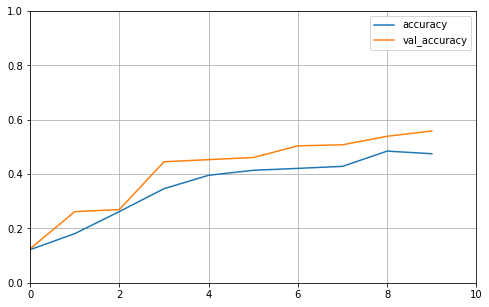

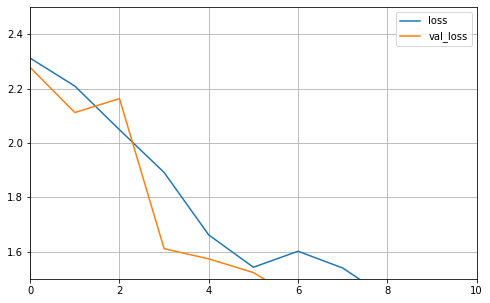

In [16]:
def plot_learning_curves(history, label, epcohs, min_value, max_value):
    data = {}
    data[label] = history.history[label]
    data['val_'+label] = history.history['val_'+label]
    pd.DataFrame(data).plot(figsize=(8, 5))
    plt.grid(True)
    plt.axis([0, epochs, min_value, max_value])
    plt.show()
#因为accuracy的值和loss值的范围很不一样，因此我们打印两条曲线
plot_learning_curves(history, 'accuracy', epochs, 0, 1)
plot_learning_curves(history, 'loss', epochs, 1.5, 2.5)